In [11]:
import warnings, math, random
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import mpl_scatter_density
import pymannkendall as mk
from datetime import datetime

from matplotlib import pyplot as plt, colors, cm
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.pyplot import MultipleLocator, FormatStrFormatter
from matplotlib.ticker import MaxNLocator, AutoLocator, ScalarFormatter
from pylab import mpl

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import t, linregress
from scipy.interpolate import make_interp_spline
from tensorflow.keras.metrics import RootMeanSquaredError

np.seterr(divide='ignore', invalid='ignore')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams["font.family"] = 'Arial'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.unicode_minus'] = False

log = math.log
pow = math.pow

def confidence(x,y):
    n = len(x)
    dof = n - 2
    alpha = 0.05
    t_value = t.ppf(1 - alpha / 2, dof)
    y_err = np.array(y) - regression_line
    s_err = np.sqrt(np.sum(y_err ** 2) / (n - 2))
    confidence_interval = t_value * s_err * np.sqrt(1 / n + (np.array(x) - np.mean(x))**2 / np.sum((np.array(x) - np.mean(x))**2))
    return confidence_interval
    
def r2(y, ypred):
    r = np.corrcoef(y, ypred)[0, 1]
    R = r ** 2 
    return R

def linear_regression(x,y):
    model = LinearRegression()
    model.fit(np.array(x).reshape(-1, 1), y)
    regression_line = model.predict(np.array(x).reshape(-1, 1))
    return regression_line

## Fig. 2 Temporal trends of global river POC flux

In [6]:
# River outlet points (INPUT): from the GitHub project folder "river_shpfile/river_point.shp"
poc = gpd.read_file(r"river_shpfile/river_point.shp")

# Global river POC dataset (INPUT): from the GitHub project file "Global river POC data.xlsx"
flux_df = pd.read_excel(r"Global river POC data.xlsx", sheet_name="sheet1")

# Land polygons (INPUT): from the GitHub project folder "river_shpfile/land_shp/ne_50m_land.shp"
world = gpd.read_file(r"river_shpfile/land_shp/ne_50m_land.shp")

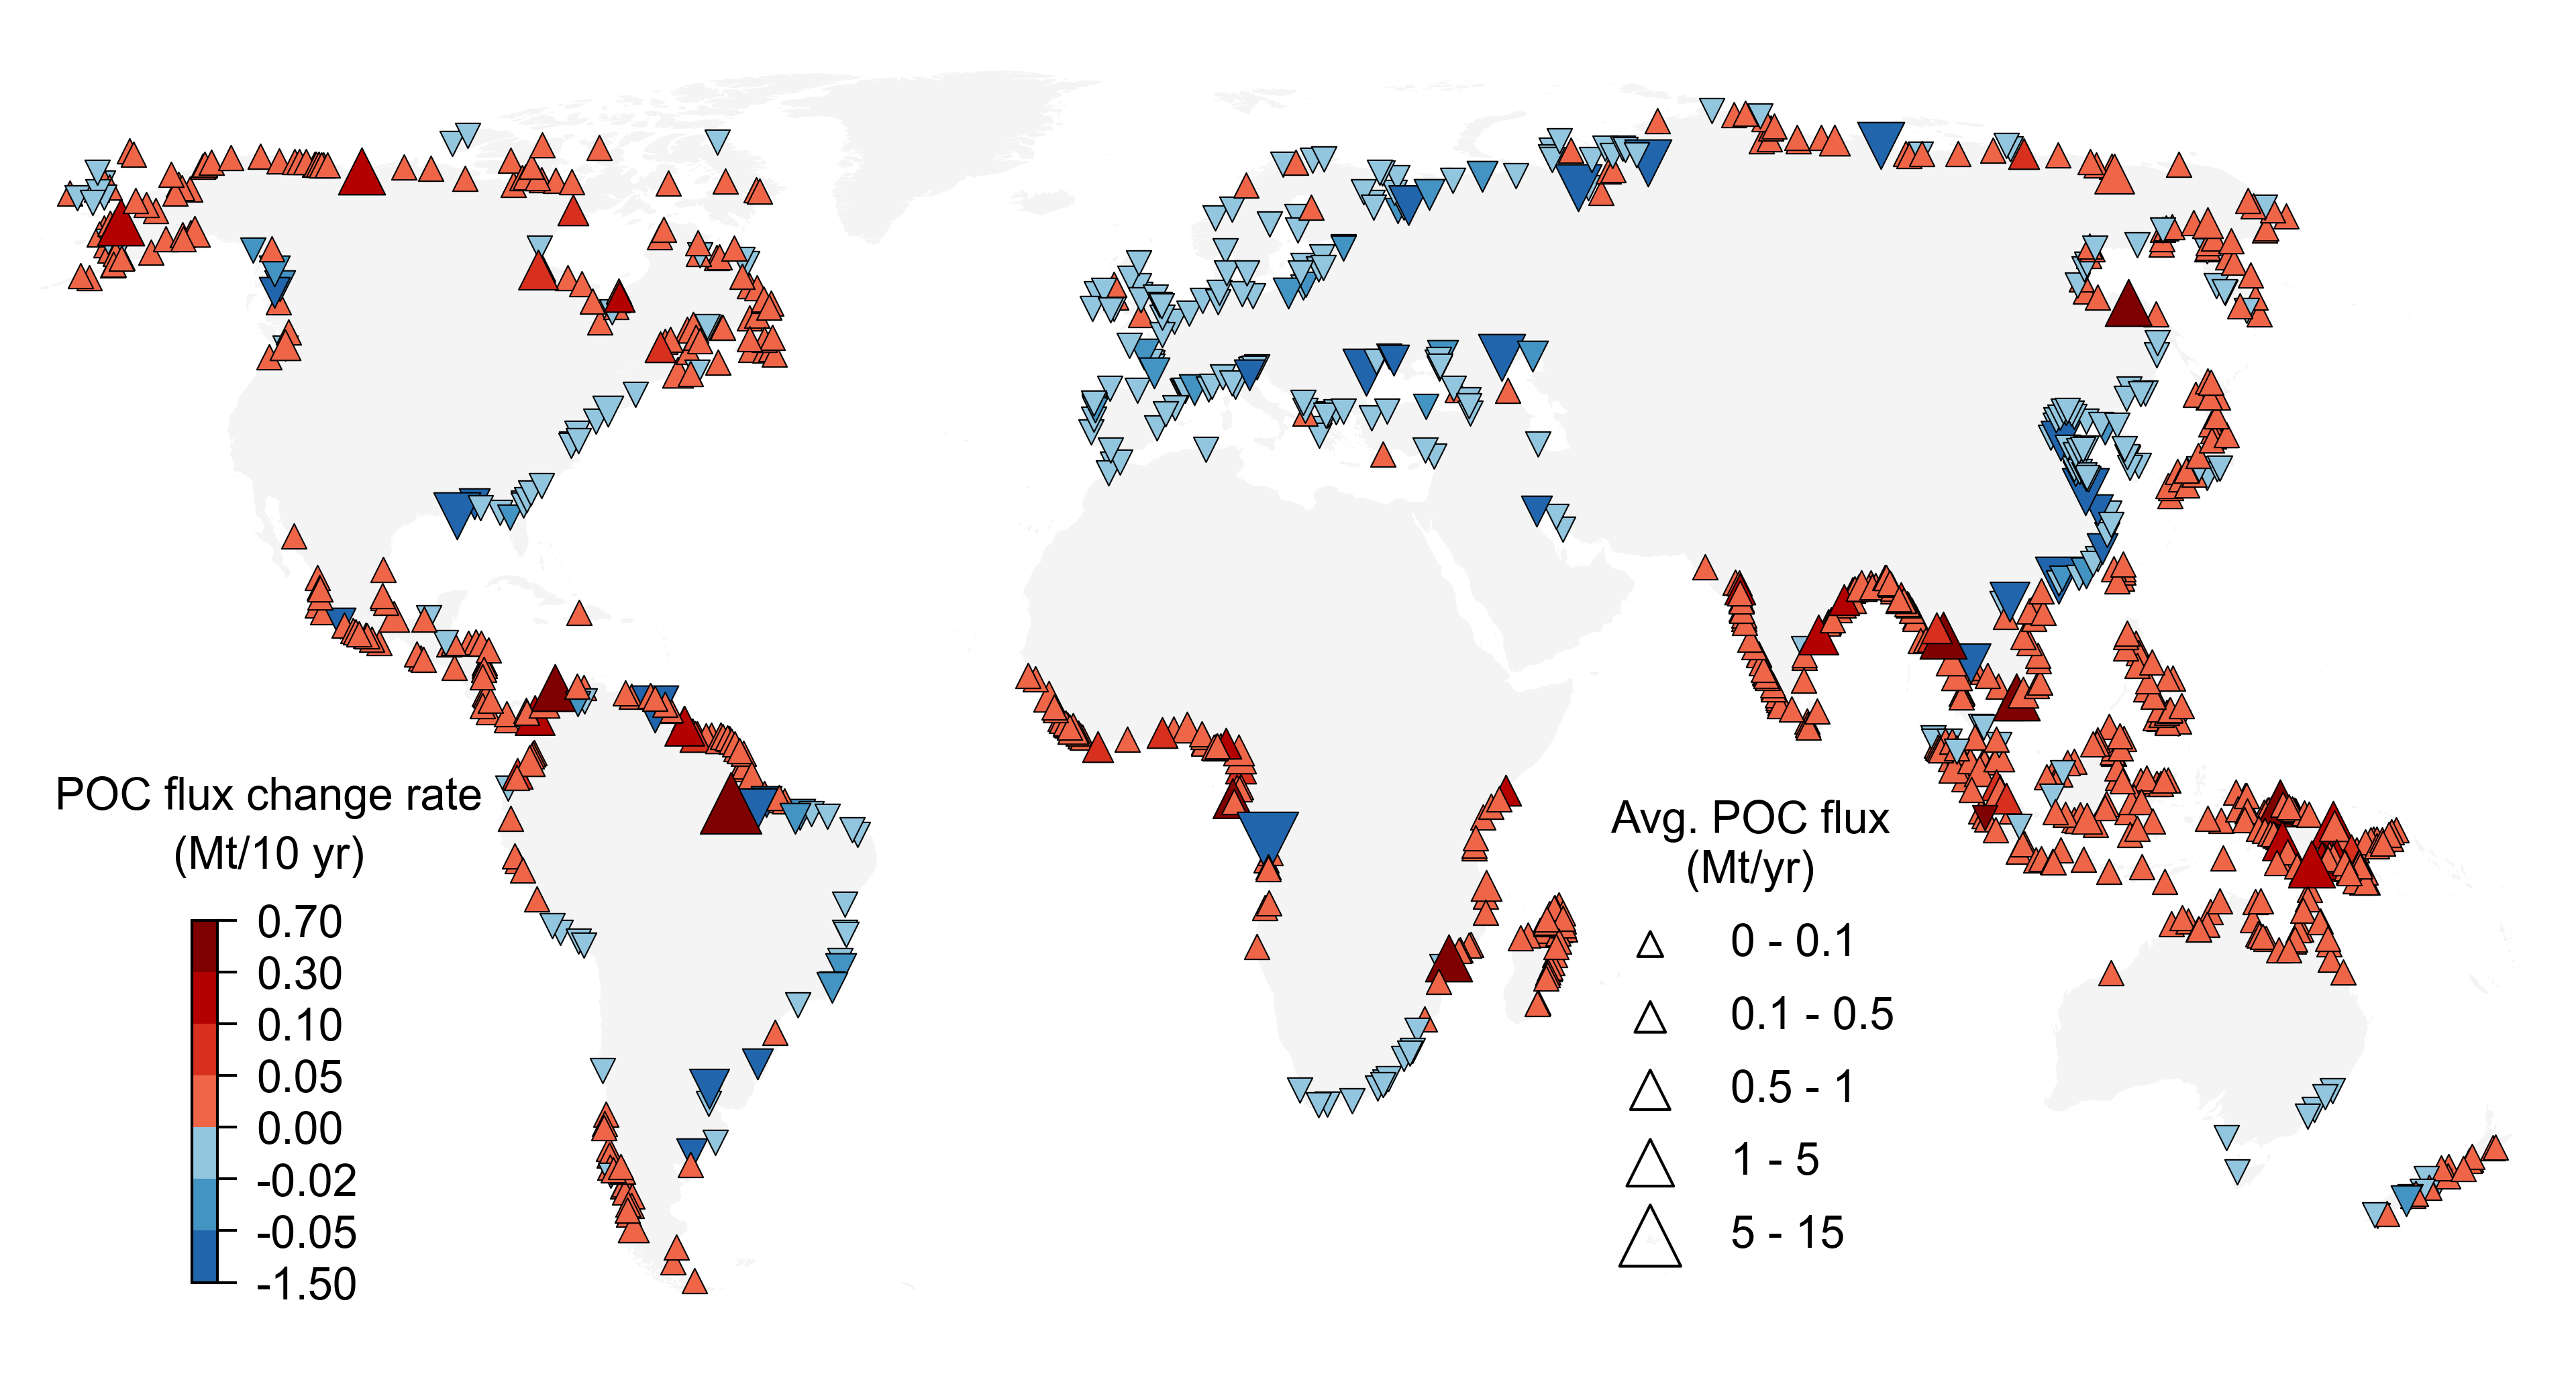

In [7]:
import warnings
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

warnings.filterwarnings('ignore', category=UserWarning)
color = 'k'
plt.rcParams.update({'axes.edgecolor': color, 'axes.labelcolor': color, 'xtick.color': color, 'ytick.color': color})

robinson_proj4 = '+proj=robin +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs'

world = world.to_crs(crs=robinson_proj4)
poc = poc.to_crs(crs=robinson_proj4)

fig, ax = plt.subplots(1, 1, figsize=(8, 7.5), dpi=600)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.axis('off')

world.plot(ax=ax, color='#EDEDED', edgecolor=None, linewidth=0.5, alpha = 0.6)

sizes = [20, 30, 50, 70, 120]
boundary = [0, 0.1, 0.5, 1, 5, 15]

poc['size'] = [sizes[0] if boundary[0] < x < boundary[1]
               else sizes[1] if boundary[1] <= x < boundary[2]
               else sizes[2] if boundary[2] <= x < boundary[3]
               else sizes[3] if boundary[3] <= x < boundary[4]
               else sizes[4] for x in poc['ave_flux']]

color_list_decrease = ['#023858','#045a8d','#ece7f2','#fff7fb']
color_list_increase = ['#7f0000','#b30000','#fee8c8','#fff7ec']

bounds = [-1.5, -0.05, -0.02, 0, 0.05, 0.1, 0.3, 0.7]

poc['color'] = [
                 '#2166ac' if (x*10 < bounds[1]) & (y == 'decreasing')
                else '#4393c3' if (bounds[1] <= x*10 < bounds[2]) & (y == 'decreasing')
                else '#92c5de' if (bounds[2] <= x*10 < bounds[3]) & (y == 'decreasing')
                else '#DEDEDE' if y == 'no trend'
                else '#ef6548'  if (bounds[3] < x*10 < bounds[4]) & (y == 'increasing')
                else '#d7301f' if (bounds[4] <= x*10 < bounds[5]) & (y == 'increasing')
                else '#b30000' if (bounds[5] <= x*10 < bounds[6]) & (y == 'increasing')
                else '#7f0000' for x,y in zip(poc['slope'], poc['trend'])]

def custom_symbol(trend):
    if trend == 'increasing':
        return '^'
    elif trend == 'decreasing':
        return 'v'
    else:
        return ''

poc['symbol'] = poc['trend'].apply(custom_symbol)

for x, y, color, symbol, size in zip(poc.geometry.x, poc.geometry.y, poc['color'], poc['symbol'], poc['size']):
    ax.scatter(x, y, marker=symbol, s=size, edgecolor='k', c=color, zorder = 100, lw = 0.25, alpha = 1)

labels = [f"{boundary[i]} - {boundary[i + 1]}" for i in range(len(boundary) - 1)] + [">1"]
legend_elements = [plt.scatter([], [], marker='^',  facecolor='none', edgecolor = 'k',lw = 0.5,s=size, label=label) for size, label in zip(sizes, labels)]
legend = plt.legend(handles=legend_elements,markerfirst=True, frameon=False, bbox_to_anchor=(0.685, 0.45),fontsize=8,labelspacing = 0.7)  

legend.set_title('Avg. POC flux\n(Mt/yr)', prop={'size': 8})
legend.get_title().set_ha("center") 
legend._legend_box.align = "center" 

color_list =  ['#2166ac', '#4393c3', '#92c5de', '#ef6548', '#d7301f', '#b30000', '#7f0000']
cmap = mcolors.ListedColormap(color_list)
bounds = bounds
norm = mcolors.BoundaryNorm(bounds, cmap.N)

cax = fig.add_axes([0.172, 0.3, 0.008, 0.12])
colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cax)
colorbar.ax.set_title('POC flux change rate\n(Mt/10 yr)', fontsize=8, x=3., y=1.05, linespacing = 1.5)
colorbar.ax.tick_params(labelsize=8)
colorbar.outline.set_linewidth(.5)
colorbar.ax.tick_params(width=.5)

ax.set_xlim(-1.3e7, 1.6e7)
ax.set_ylim(-6.5e6, 8.7e6)

plt.show()

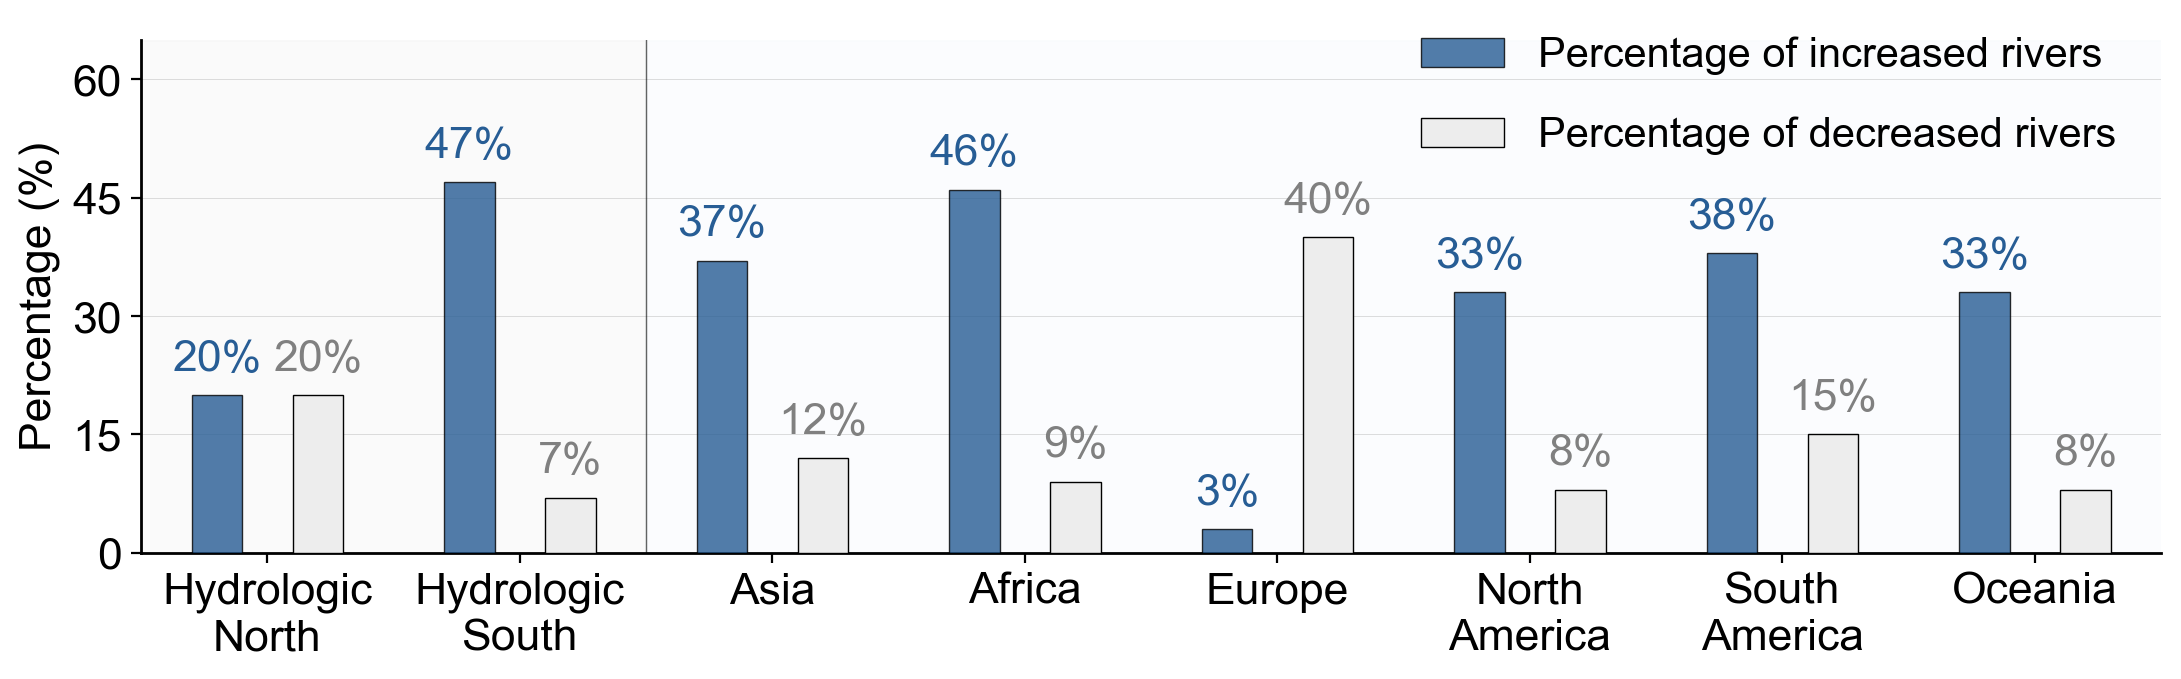

In [8]:
poc["lat"] = poc.geometry.y

regions = {
    "Hydrologic\nNorth": poc[poc["lat"] >= 20],
    "Hydrologic\nSouth": poc[poc["lat"] < 20],
    "Asia": poc[poc["continent"]=="Asia"],
    "Africa": poc[poc["continent"]=="Africa"],
    "Europe": poc[poc["continent"]=="Europe"],
    "North\nAmerica": poc[poc["continent"]=="North America"],
    "South\nAmerica": poc[poc["continent"]=="South America"],
    "Oceania": poc[poc["continent"]=="Oceania"]
}

inc_list = [round((g["trend"]=="increasing").mean()*100) for g in regions.values()]
dec_list = [round((g["trend"]=="decreasing").mean()*100) for g in regions.values()]

inc_counts = [((g["trend"]=="increasing")).sum() for g in regions.values()]
dec_counts = [((g["trend"]=="decreasing")).sum() for g in regions.values()]
total_counts = [len(g) for g in regions.values()]

region_names = list(regions.keys())

inc_counts = [((g["trend"]=="increasing")).sum() for g in regions.values()]
dec_counts = [((g["trend"]=="decreasing")).sum() for g in regions.values()]
total_counts = [len(g) for g in regions.values()]

plt.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.size'] = 16

continents = ['Hydrologic\nNorth', 'Hydrologic\nSouth', 'Asia', 'Africa', 'Europe', 'North\nAmerica', 'South\nAmerica', 'Oceania']
increase = inc_list
decrease = dec_list
no_trend = [100 - (inc + dec) for inc, dec in zip(increase, decrease)]

bar_width = 0.2
spacing = 0.2

x = np.arange(len(continents))

fig, ax = plt.subplots(figsize=(11.5, 3.7), dpi = 200)

bars1 = ax.bar(x - bar_width/2 - spacing/2, increase, bar_width, color='#275d95', label='Percentage of increased rivers',
               edgecolor='k', linewidth=0.5, alpha = 0.8, zorder = 100)
bars2 = ax.bar(x + bar_width/2 + spacing/2, decrease, bar_width, color='#EDEDED', label='Percentage of decreased rivers', 
               edgecolor='k', linewidth=0.5,alpha = 1, zorder = 100)

for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, str(yval)+'%', ha='center', va='bottom', color = '#275d95')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, str(yval)+'%', ha='center', va='bottom',color='gray')

ax.set(ylim=(0, 65), xlim=(-0.5, 7.5))

ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(continents)
ax.legend(markerfirst=True, ncol=1, frameon=False, loc='upper left', bbox_to_anchor=(0.615, 1.08), labelspacing=1, fontsize = 15)
ax.grid(axis='y', zorder=-10, alpha=0.5, lw=0.3)
ax.yaxis.set_major_locator(MultipleLocator(15))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=1.5, linestyle='solid', color='k', alpha=0.6, lw = 0.5)
ax.axvspan(-1, 1.5, color='lightgray', alpha=0.1)
ax.axvspan(1.5, 8, color='#deebf7', alpha=0.1)

plt.tight_layout()
plt.show()

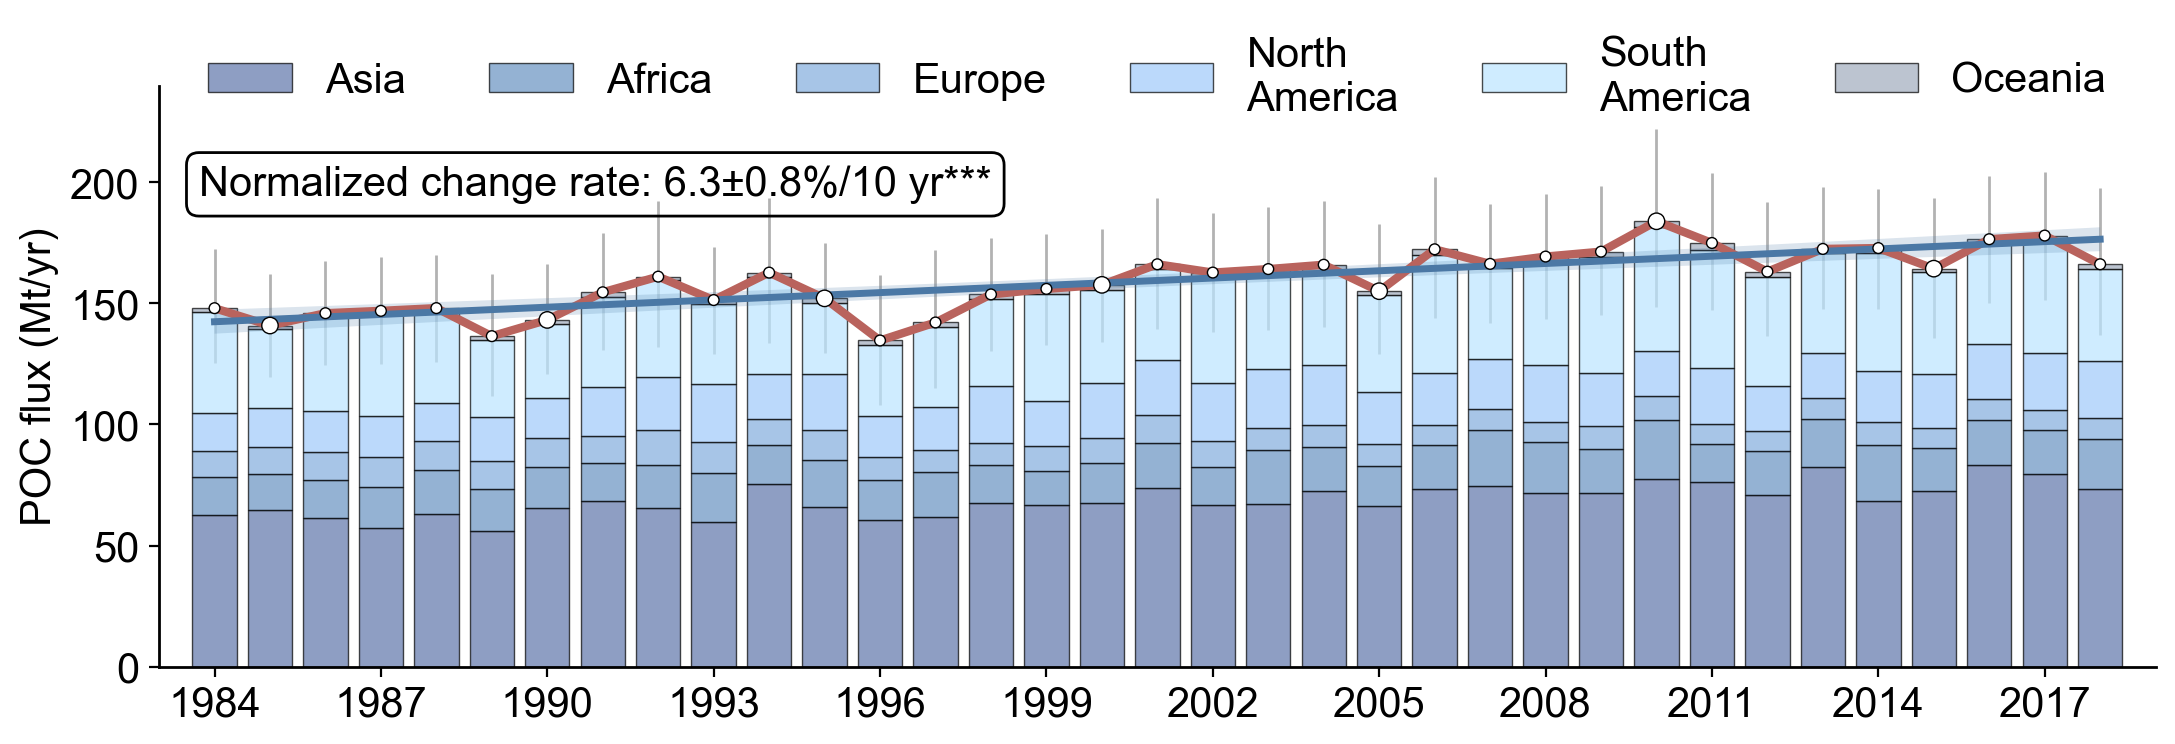

In [9]:
mpl.rcParams['font.size'] = 15

continents = ['Asia', 'Africa', 'Europe', 'North America', 'South America', 'Oceania']

years = np.arange(1984, 2019)

row_mean = flux_df[years].mean(axis=1, skipna=True)

flux_df[years] = flux_df[years].apply(lambda col: col.fillna(row_mean))

flux_by_continent = {}

for cont in continents:
    ids = poc.loc[poc["continent"] == cont, "ID"]
    sub = flux_df[flux_df["ID"].isin(ids)]
    flux_by_continent[cont] = sub[years].sum().values

fig, ax = plt.subplots(figsize=(11.5, 4.), dpi=200)

colors = ['#5F75AA','#6792C1','#83ADDD','#9FC9FA','#BCE5FF','#A0ACBD']

bottom = np.zeros(len(years))

for cont, col in zip(continents, colors):
    ax.bar(years, flux_by_continent[cont], 0.8,bottom=bottom, label=cont, color=col, edgecolor='black', linewidth=0.5, alpha = 0.7)
    bottom += flux_by_continent[cont]

s = flux_df[years].sum().values
slope, intercept, r_value, p_value, std_err = linregress(years, s)
mean_val = s.mean()
norm_rate = (slope / mean_val) * 1000

# -------------------
ax.plot(years, s, color='#B9635D', lw=3)
ax.scatter(years, s,s=np.where(years % 5 == 0, 35, 15),facecolors='white', edgecolors='black', zorder=12, linewidths=0.5)
regression_line = linear_regression(years, s)
line = ax.plot(years, regression_line, color='#4B78A5', lw = 2.5)

# yerr is derived from 5,000 Monte Carlo simulations
yerr = np.array([[22.84, 21.29, 21.53, 21.79, 22.09, 24.59, 22.47, 23.92, 29.14,
        22.27, 28.94, 22.37, 26.54, 27.1 , 23.48, 23.38, 23.59, 26.91,
        24.37, 25.12, 25.83, 25.95, 28.45, 24.34, 25.7 , 26.23, 35.21,
        27.71, 26.55, 24.98, 25.32, 28.44, 26.19, 26.47, 29.2 ],
       [24.51, 21.11, 21.57, 22.09, 21.89, 25.72, 23.16, 24.62, 31.3 ,
        21.92, 30.63, 23.02, 26.86, 30.03, 23.49, 22.65, 22.95, 27.39,
        24.59, 25.52, 26.19, 27.56, 29.84, 24.63, 25.88, 27.07, 38.08,
        28.98, 28.85, 25.63, 24.56, 29.23, 26.16, 26.29, 31.61]])

ax.errorbar(years, s, yerr=yerr, fmt="none", ecolor="grey", elinewidth=1, capsize=0, alpha=0.6, zorder=-100)

confidence_interval = confidence(years, s)
ax.fill_between(years, regression_line - confidence_interval, regression_line + confidence_interval, color= '#4B78A5', alpha=0.2, edgecolor='none', linestyle='-', lw=1)

ax.set(ylim = (0,240), xlim = (1983, 2019))
ax.set_xticks(np.arange(1984, 2019, 3))

ax.text(0.02,0.83, 'Normalized change rate: {}±{}%/10 yr***'.format(round((slope/mean_val) * 1000,1), round((std_err/s.mean()) * 1000,1)), transform=ax.transAxes,ha='left', va='center',linespacing=1.7, bbox=dict(edgecolor='black',  facecolor = 'none', boxstyle='round,pad=0.3',  ))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("POC flux (Mt/yr)")
ax.legend(handles=ax.get_legend_handles_labels()[0], labels=['Asia', 'Africa', 'Europe', 'North\nAmerica', 'South\nAmerica', 'Oceania'], markerfirst=True, ncol=6, frameon=False,columnspacing=2,bbox_to_anchor=(0.5, 1.15),loc='upper center')

plt.tight_layout()
plt.show()

## Number of Landsat images

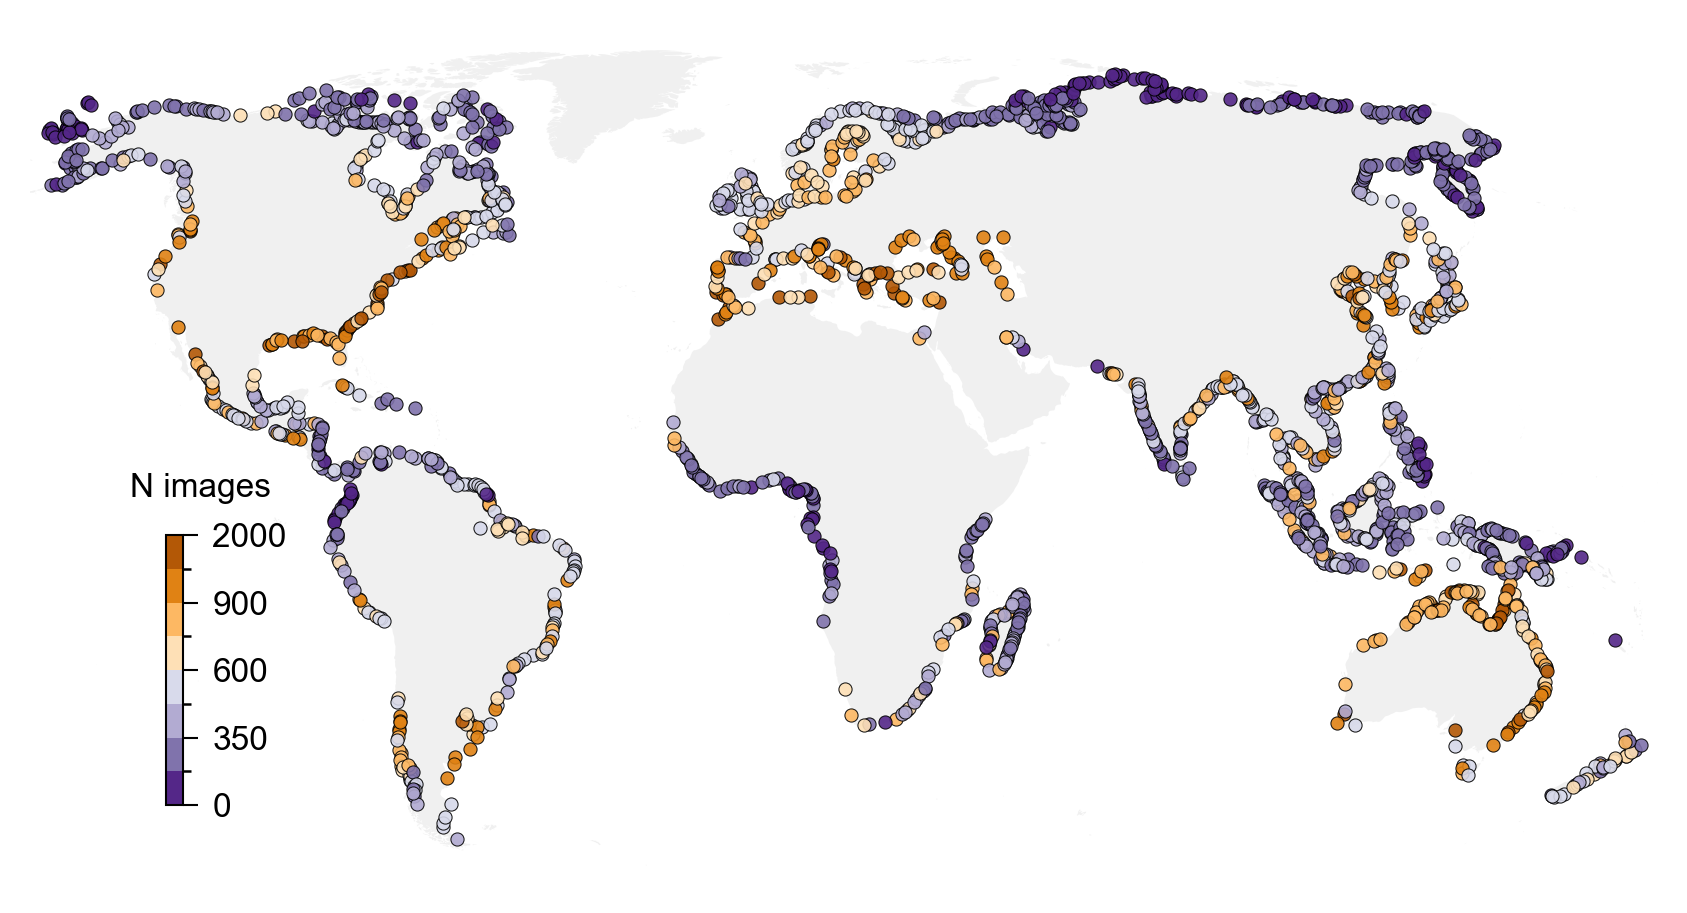

In [75]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore', category=FutureWarning)
mpl.rcParams['font.size'] = 12

robinson_proj4 = '+proj=robin +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs'
world = world.to_crs(crs=robinson_proj4)
poc = poc.to_crs(crs=robinson_proj4)

fig, ax = plt.subplots(1, 1, figsize=(7, 7.5), dpi=300)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.axis('off')

world.plot(ax=ax, color='#EDEDED', edgecolor=None, linewidth=0.5, alpha = 0.8)

color_list = ['#b35806','#e08214','#fdb863','#fee0b6','#d8daeb','#b2abd2','#8073ac','#542788']
color_list.reverse()
bounds = [200, 350, 450, 600, 700, 900, 1200, 2000]

poc['color'] = [color_list[0] if (x < bounds[0])
                else color_list[1] if (bounds[0] <= x < bounds[1])
                else color_list[2] if (bounds[1] <= x < bounds[2])
                else color_list[3] if (bounds[2] <= x < bounds[3])
                else color_list[4] if (bounds[3] <= x < bounds[4])
                else color_list[5] if (bounds[4] <= x < bounds[5])
                else color_list[6] if (bounds[5] <= x < bounds[6])
                else color_list[7] for x in poc['image_num']]

for x, y, color, in zip(poc.geometry.x, poc.geometry.y, poc['color']):
    ax.scatter(x, y,  s = 10, edgecolor='k', c=color, zorder = 100, lw = 0.25, alpha = 0.9)

cmap = mcolors.ListedColormap(color_list)
norm = mcolors.BoundaryNorm([0, 200, 350, 450, 600, 700, 900, 1200, 2000], cmap.N)

cax = fig.add_axes([0.19, 0.34, 0.008, 0.12])
colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cax)

colorbar.set_ticks([0, 350,  600, 900,  2000])
colorbar.set_ticklabels([0, 350,  600, 900,2000])

colorbar.ax.set_title('N images',  fontsize=8, x=2, y=1.05, linespacing = 1.2)
colorbar.ax.tick_params(labelsize=8)
colorbar.outline.set_linewidth(.5)
colorbar.ax.tick_params(width=.5)
# plt.tight_layout()

ax.set_xlim(-1.3e7, 1.6e7)
ax.set_ylim(-6.5e6, 8.7e6)
plt.show()

## Optical water tpyes

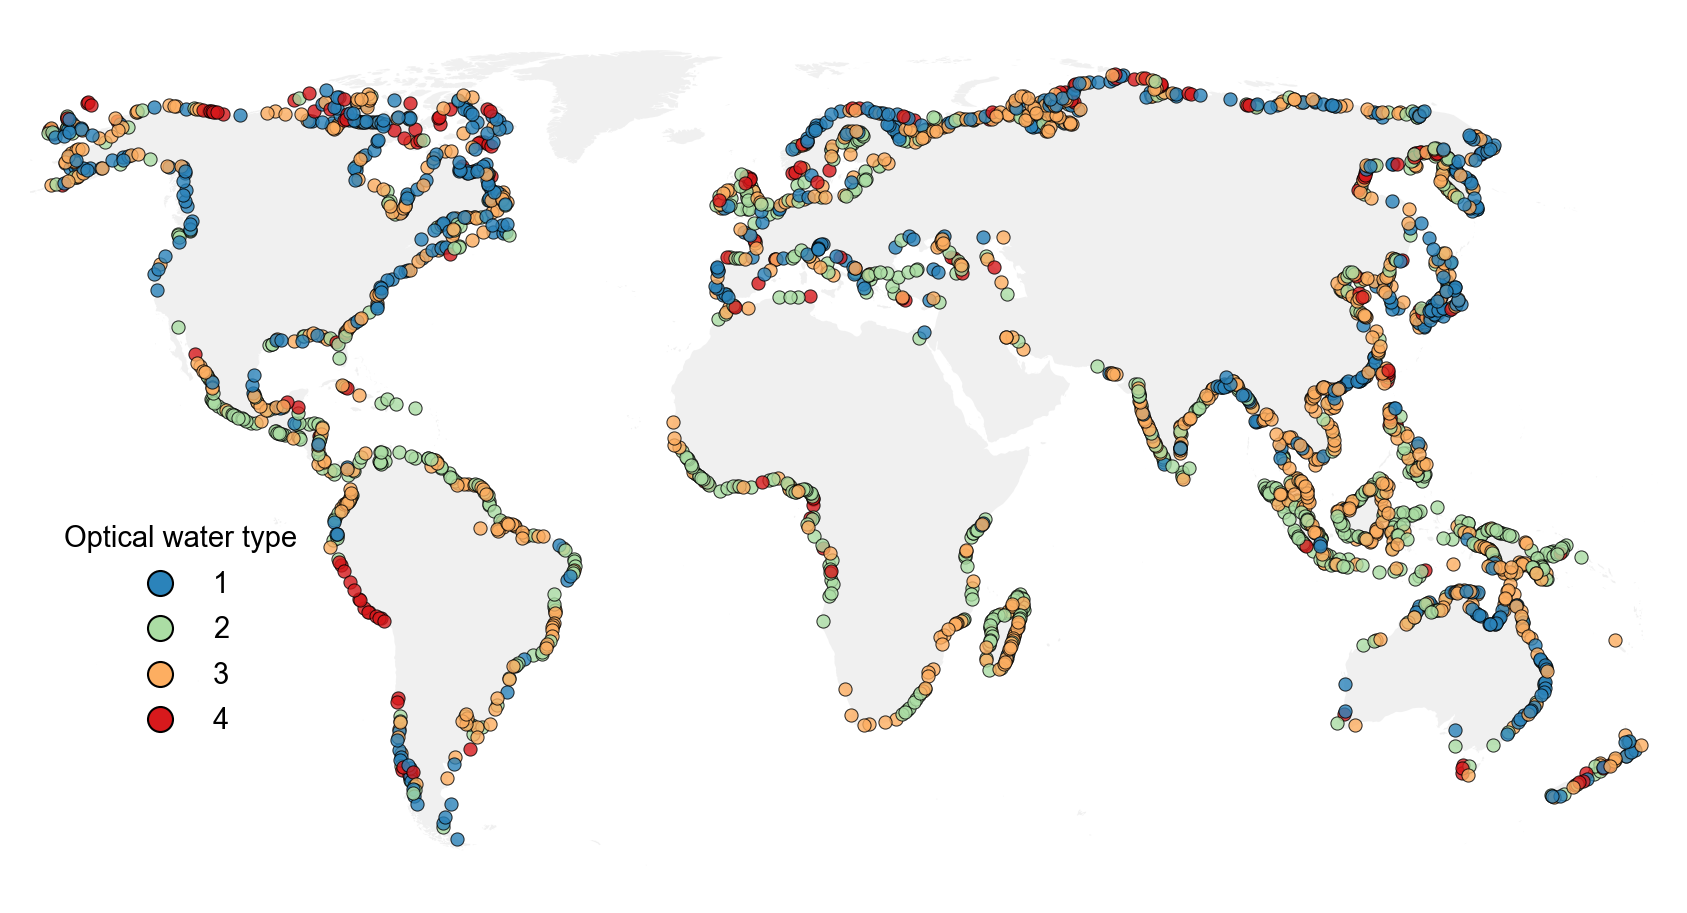

In [79]:
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', category=FutureWarning)
mpl.rcParams['font.size'] = 12

robinson_proj4 = '+proj=robin +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs'
world = world.to_crs(crs=robinson_proj4)
poc = poc.to_crs(crs=robinson_proj4)

fig, ax = plt.subplots(1, 1, figsize=(7, 7.5), dpi=300)
for s in ['top', 'right', 'bottom', 'left']:
    ax.spines[s].set_visible(False)
ax.axis('off')

world.plot(ax=ax, color='#EDEDED', edgecolor=None, linewidth=0.5, alpha=0.8)

color_list = ['#d7191c', '#fdae61', '#abdda4', '#2b83ba']
color_list.reverse()
bounds = [0, 1, 2, 3, 4]

poc['color'] = [
    color_list[0] if (x == bounds[1])
    else color_list[1] if (x == bounds[2])
    else color_list[2] if (x == bounds[3])
    else color_list[3]
    for x in poc['OWT']
]

for x, y, c in zip(poc.geometry.x, poc.geometry.y, poc['color']):
    ax.scatter(x, y, s=10, edgecolor='k', c=c, zorder=100, lw=0.25, alpha=0.8)


owt_vals = [1, 2, 3, 4]
owt_colors = [color_list[0], color_list[1], color_list[2], color_list[3]]

legend_elements_owt = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=c, markeredgecolor='k',
           markeredgewidth=0.5,
           markersize=6,
           label=str(v))
    for v, c in zip(owt_vals, owt_colors)
]

legend_owt = ax.legend(
    handles=legend_elements_owt,
    title='Optical water type',
    markerfirst=True,
    frameon=False,
    bbox_to_anchor=(0.18, 0.45),
    fontsize=7,
    title_fontsize=7,
    labelspacing=0.6
)

ax.set_xlim(-1.3e7, 1.6e7)
ax.set_ylim(-6.5e6, 8.7e6)

plt.show()

## Sensetive analysis

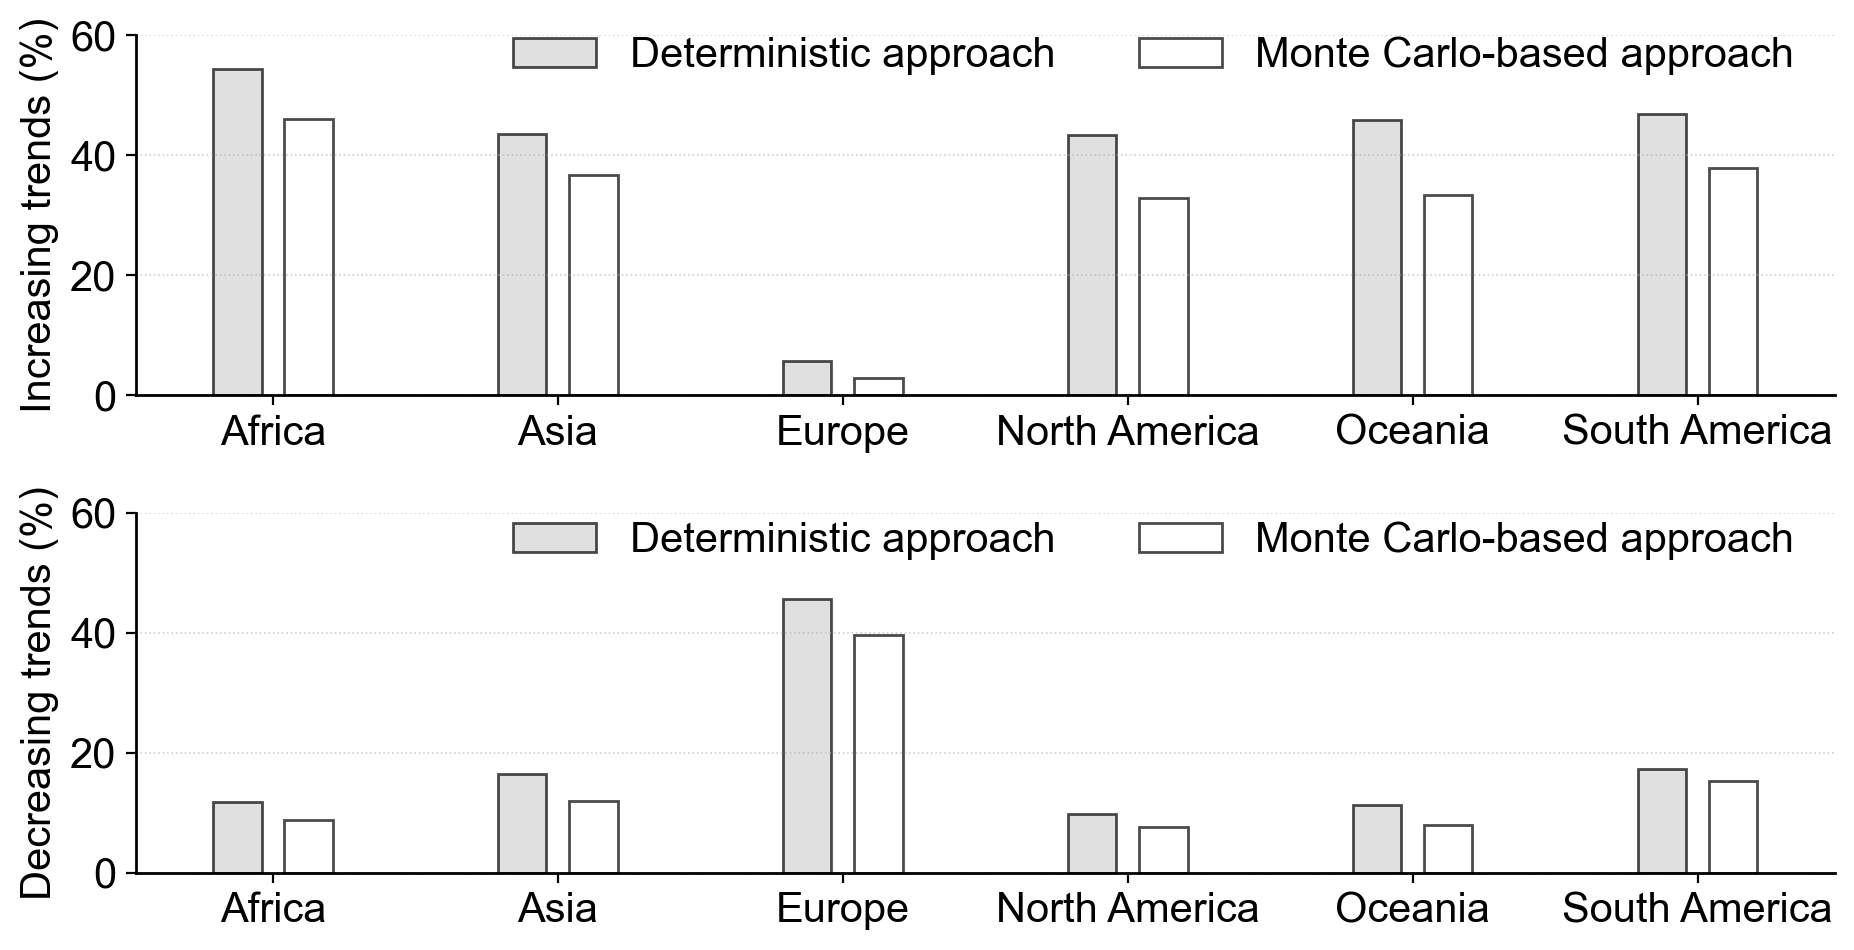

In [10]:
mpl.rcParams['font.size'] = 15

# trend: Monte Carlo–based approach; trend2: Deterministic approach
for c in ["continent", "trend", "trend2"]:
    poc[c] = poc[c].astype(str).str.strip()
    
poc["trend"]  = poc["trend"].str.lower()
poc["trend2"] = poc["trend2"].str.lower()

continents = sorted(poc["continent"].dropna().unique())
x = np.arange(len(continents))

def ratio(col, label):
    return (poc.assign(flag=poc[col].eq(label))
              .groupby("continent")["flag"].mean()
              .reindex(continents).fillna(0).values * 100)

vals = {
    "Increasing trends (%)": (ratio("trend","increasing"),  ratio("trend2","increasing"), (0,60)),
    "Decreasing trends (%)": (ratio("trend","decreasing"),  ratio("trend2","decreasing"), (0,60)),
}

w = 0.17
pair_gap = 0.25
lw = 1
labels = ( "Deterministic approach", "Monte Carlo-based approach",)
colors = ("lightgrey", "white")

fig, ax = plt.subplots(2, 1, figsize=(10, 5), dpi=200, sharex=False)

for a, (ylab, (v1, v2, ylim)) in zip(ax, vals.items()):
    a.bar(x - pair_gap/2, v2, width=w, edgecolor="k", linewidth=lw, color=colors[0], label=labels[0], alpha = 0.7)
    a.bar(x + pair_gap/2, v1, width=w, edgecolor="k", linewidth=lw, color=colors[1], label=labels[1], alpha = 0.7)
    a.set_ylabel(ylab)
    a.set_xticks(x); a.set_xticklabels(continents)
    a.set_ylim(*ylim)
    a.grid(True, axis="y", ls=":", lw=0.6, alpha=0.6)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

ax[0].legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(0.2, 1.1))
ax[1].legend(ncol=2, frameon=False, loc='upper left', bbox_to_anchor=(0.2, 1.08))

plt.tight_layout()
plt.show()

## Attribution analysis

In [ ]:
import ee, os
import geemap
import numpy as np, pandas as pd, geopandas as gpd, shap
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split

ee.Authenticate()
ee.Initialize()

os.environ['HTTP_PROXY'] = 'http://127.0.0.1:7897' 
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:7897'

In [ ]:
dam = gpd.read_file(r'Global Dam Watch (GDW) database (source: https://www.globaldamwatch.org/database)')

dams_1984 = dam[(dam['CAP_MCM'] > 0) & (dam['YEAR_DAM'] > 1984)]

# Basin polygons (INPUT): replace the path with your own basin shapefile.
# The shapefile must contain an "ID" field for basin identifiers.
basin = gpd.read_file(r"PATH/TO/YOUR/basin_shapefile.shp")

results = []

for id in tqdm(basin['ID'], desc="Basins"):
    basin_shp =  basin[basin['ID'] == id]
    geometry = geemap.geopandas_to_ee(basin_shp)
    Map.addLayer(geometry, {}, 'Geometry')
    Map.centerObject(geometry, 6)

    pts = gpd.sjoin(filtered_river, basin_shp[["geometry"]], how="inner", predicate="within").drop(columns="index_right")

    if pts.empty:
        continue
        
    ids = pts["ID"].astype(int).tolist()
    id_maxQ = int(pts.loc[pts["discharge"].astype(float).idxmax(), "ID"])

    for year in range(2000, 2019):

        intersecting_dams = gpd.sjoin(dams_1984, basin_shp, how='inner', op='intersects')

        intersecting_dams = intersecting_dams[intersecting_dams['YEAR_DAM'] <= year]
                
        num_dams_in_basin = intersecting_dams.shape[0]
                
        reservior_capacity = round(sum(intersecting_dams['CAP_MCM'].tolist())*0.001,2)

        poc_maxQ = ssc_df.loc[ssc_df.ID.eq(id_maxQ), year].to_numpy()
        poc_maxQ = poc_maxQ[0] if len(poc_maxQ) else np.nan
        poc_mean = ssc_df.loc[ssc_df.ID.isin(ids), year].mean()

        threshold = 20; scale_hansen = 5000
        dataset = ee.Image('UMD/hansen/global_forest_change_2024_v1_12')
        
        tree_cover = dataset.select('treecover2000').gte(threshold).selfMask().clip(geometry)
        forest_area_km2 = tree_cover.multiply(ee.Image.pixelArea()).reduceRegion(reducer=ee.Reducer.sum(), geometry=geometry.geometry(), scale=scale_hansen, maxPixels=1e13).get('treecover2000').getInfo() / 1_000_000
        
        if (year < 2001) or (year > 2024) or (forest_area_km2 == 0):
            deforestation = np.nan; loss_area_km2 = np.nan
        else:
            loss = dataset.select('lossyear').eq(year - 2000).selfMask().clip(geometry)
            loss_area_km2 = loss.multiply(ee.Image.pixelArea()).reduceRegion(
                reducer=ee.Reducer.sum(), geometry=geometry.geometry(), scale=scale_hansen, maxPixels=1e13
            ).get('lossyear').getInfo() / 1_000_000
        
            gain = dataset.select('gain').updateMask(dataset.select('gain')).clip(geometry)
            gain_area_km2 = gain.multiply(ee.Image.pixelArea()).reduceRegion(
                reducer=ee.Reducer.sum(), geometry=geometry.geometry(), scale=scale_hansen, maxPixels=1e13
            ).get('gain').getInfo() / 1_000_000
        
            deforestation = (loss_area_km2 - gain_area_km2) / forest_area_km2
    

        try:
            ndvi = ee.ImageCollection('NOAA/CDR/AVHRR/NDVI/V5').filterDate(f'{year}-01-01', f'{year}-12-31').mean() \
                .select('NDVI').clip(geometry) \
                .reduceRegion(reducer=ee.Reducer.mean(),geometry=geometry,scale=5000,maxPixels=1e13) \
                .get('NDVI').getInfo()
        except:
            ndvi = 0

        try:
            prec =  ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
                .filterDate(f'{year}-01-01', f'{year}-12-31') \
                .sum().clip(geometry) \
                .reduceRegion(reducer=ee.Reducer.mean(),geometry=geometry,scale=10000).getInfo().get('total_precipitation_sum')
        except:
            prec = 0

        try:
            era5_data = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
                        .filterDate(f'{year}-01-01', f'{year}-12-31').mean().clip(geometry) \
                        .reduceRegion(reducer=ee.Reducer.mean(),geometry=geometry,scale=10000).getInfo()
            
            temp = era5_data.get('temperature_2m', 0)
            runoff = era5_data.get('surface_runoff_sum', 0)
            evaporation = era5_data.get('total_evaporation_sum', 0)
            
        except:
            temp = runoff = evaporation = 0
        

        year_data = {'id': id,'year': year, 'POC_max': poc_maxQ,  'POC_mean': poc_mean, 'deforestation': deforestation, 'loss_area_km2': loss_area_km2, 'num_dams_in_basin': num_dams_in_basin, 'reservior_capacity': reservior_capacity, 'ndvi': ndvi, 'temp': temp, 'prec': prec, 'runoff': runoff, 'evaporation': evaporation}
        
        results.append(year_data)
        # print(id, year, 'finished', sep = '\t')
        
df = pd.DataFrame(results)

In [ ]:
out = []

for id in basin['ID']:
    if id not in df['id'].unique():
        print(id, 'temp', sep = '\t')
        out.append([id, 'temp'])
        continue
        
    filter_df = df[df['id'] == id]

    features = ["loss_area_km2", "reservior_capacity", "temp", "prec", 'num_dams_in_basin']
    
    drop_feats = [c for c in ["deforestation", "loss_area_km2"] if filter_df[c].notna().sum() == 0]
    current_features = [c for c in features if c not in drop_feats]
    
    tmp = filter_df[current_features + ["POC_max"]].dropna().reset_index(drop=True)

    X = tmp[current_features]
    y = tmp["POC_max"]
    
    iteration_winners = []
    
    for i in range(100):
        rf = RandomForestRegressor(n_estimators=100, random_state=i, n_jobs = -1)
        rf.fit(X, y)
        
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X)
        
        shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=current_features)
        
        iteration_winners.append(shap_importance.idxmax())

    most_common_feature = Counter(iteration_winners).most_common(1)[0][0]

    print(id, most_common_feature, sep = '\t')
    out.append([id, most_common_feature])

out_df = pd.DataFrame(out, columns=["id", "driver"])